In [1]:
!pip install netCDF4 h5py xarray matplotlib numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.4 MB/s eta 0:00:00


In [2]:
!pip install boto3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 9.5 MB/s eta 0:00:00


In [3]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import os

# Anonymous access - no login needed
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

bucket = 'noaa-goes19'
prefix = 'ABI-L1b-RadC/2025/180/12/'  # Day 180 = June 29

# List available files
response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix, MaxKeys=5)

for obj in response['Contents']:
    print(obj['Key'])

ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801201175_e20251801203548_c20251801203595.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801206175_e20251801208548_c20251801208588.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801211175_e20251801213548_c20251801213594.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801216175_e20251801218548_c20251801219005.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801221175_e20251801223548_c20251801223586.nc


In [4]:
# C13 = Channel 13 = Thermal Infrared - yahi chahiye humhe
prefix = 'ABI-L1b-RadC/2025/180/12/'

response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix, MaxKeys=20)

# Sirf C13 files filter karo
c13_files = [obj['Key'] for obj in response['Contents'] if 'C13' in obj['Key']]

for f in c13_files:
    print(f)

In [5]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config

s3 = boto3.client(
    's3',
    config=Config(signature_version=UNSIGNED)
)

bucket = "noaa-goes19"

In [6]:
response = s3.list_objects_v2(
    Bucket=bucket,
    Prefix="ABI-L1b-RadC/2025/180/12/",
    MaxKeys=5
)

for obj in response["Contents"]:
    print(obj["Key"])

ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801201175_e20251801203548_c20251801203595.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801206175_e20251801208548_c20251801208588.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801211175_e20251801213548_c20251801213594.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801216175_e20251801218548_c20251801219005.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801221175_e20251801223548_c20251801223586.nc


In [7]:
key = "ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801201175_e20251801203548_c20251801203595.nc"

s3.download_file(
    bucket,
    key,
    "sample.nc"
)

print("Downloaded")

Downloaded


In [8]:
import netCDF4 as nc

ds = nc.Dataset("sample.nc")

print(ds.variables.keys())

dict_keys(['Rad', 'DQF', 't', 'y', 'x', 'time_bounds', 'goes_imager_projection', 'y_image', 'y_image_bounds', 'x_image', 'x_image_bounds', 'nominal_satellite_subpoint_lat', 'nominal_satellite_subpoint_lon', 'nominal_satellite_height', 'geospatial_lat_lon_extent', 'yaw_flip_flag', 'band_id', 'band_wavelength', 'esun', 'kappa0', 'planck_fk1', 'planck_fk2', 'planck_bc1', 'planck_bc2', 'a_h_NRTH', 'b_h_NRTH', 'valid_pixel_count', 'missing_pixel_count', 'saturated_pixel_count', 'undersaturated_pixel_count', 'focal_plane_temperature_threshold_exceeded_count', 'min_radiance_value_of_valid_pixels', 'max_radiance_value_of_valid_pixels', 'mean_radiance_value_of_valid_pixels', 'std_dev_radiance_value_of_valid_pixels', 'maximum_focal_plane_temperature', 'focal_plane_temperature_threshold_increasing', 'focal_plane_temperature_threshold_decreasing', 'percent_uncorrectable_L0_errors', 'earth_sun_distance_anomaly_in_AU', 'algorithm_dynamic_input_data_container', 'processing_parm_version_container', 'a

In [9]:
img = ds.variables['Rad'][:]

print(img.shape)
print(img.min())
print(img.max())

(3000, 5000)
-0.76135063
474.3209


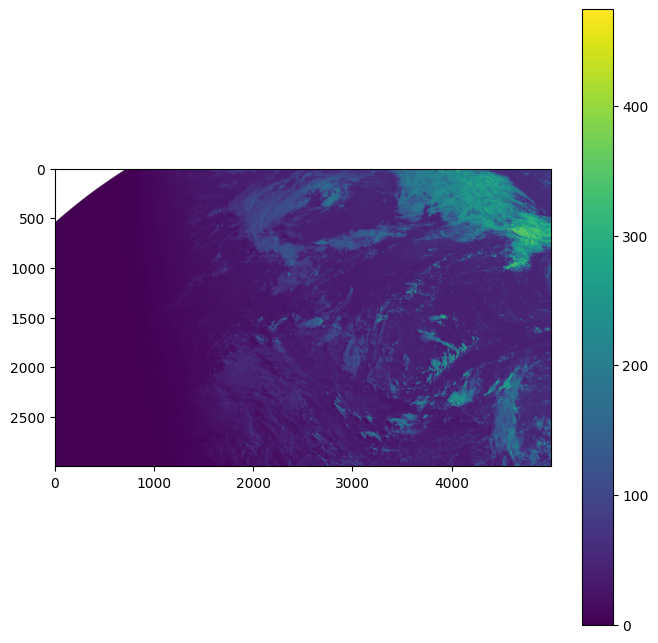

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.colorbar()
plt.show()

In [11]:
response = s3.list_objects_v2(
    Bucket=bucket,
    Prefix="ABI-L1b-RadC/2025/180/12/",
    MaxKeys=20
)

for obj in response["Contents"]:
    print(obj["Key"])

ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801201175_e20251801203548_c20251801203595.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801206175_e20251801208548_c20251801208588.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801211175_e20251801213548_c20251801213594.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801216175_e20251801218548_c20251801219005.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801221175_e20251801223548_c20251801223586.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801226175_e20251801228548_c20251801228593.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801231175_e20251801233548_c20251801233588.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801236175_e20251801238548_c20251801238589.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801241175_e20251801243548_c20251801243589.nc
ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801246175_e20251801248548

In [12]:
key1 = "ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C01_G19_s20251801201175_e20251801203548_c20251801203595.nc"

key2 = "ABI-L1b-RadC/2025/180/12/OR_ABI-L1b-RadC-M6C02_G19_s20251801236175_e20251801238548_c20251801238577.nc"

s3.download_file(bucket, key1, "frame1.nc")
s3.download_file(bucket, key2, "frame2.nc")

print("Downloaded both files")

Downloaded both files


In [13]:
ds1 = nc.Dataset("frame1.nc")
ds2 = nc.Dataset("frame2.nc")

img1 = ds1.variables["Rad"][:]
img2 = ds2.variables["Rad"][:]

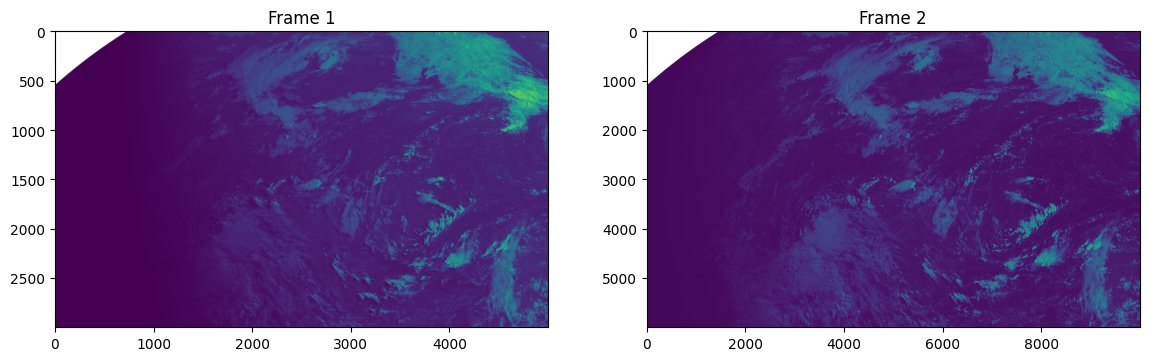

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14,6))

ax[0].imshow(img1)
ax[0].set_title("Frame 1")

ax[1].imshow(img2)
ax[1].set_title("Frame 2")

plt.show()

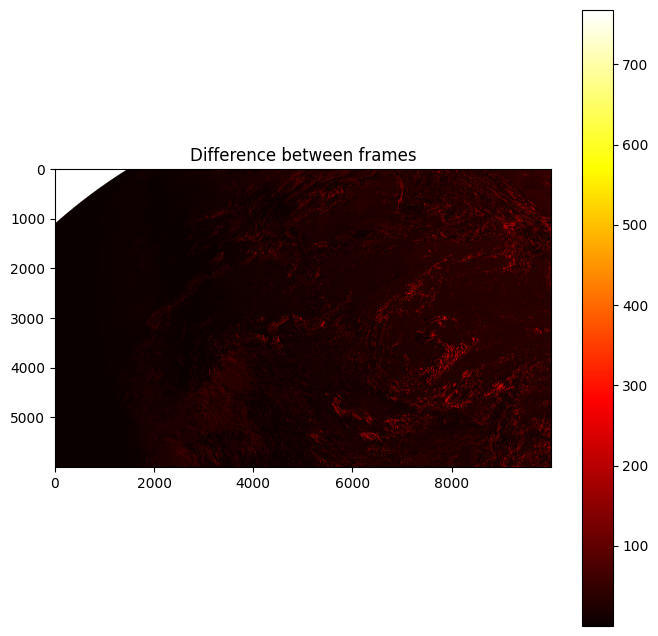

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Original code was: diff = np.abs(img2 - img1)
# This caused ValueError because img1 and img2 have different shapes.
# img2 has shape (6000,10000) and img1 has shape (3000,5000) from the traceback.

# To fix this, we need to ensure both images have the same shape.
# We will resize img1 to match the shape of img2.
# Note: Resizing involves interpolation and might alter the data,
# so for precise scientific analysis, it's better to ensure data
# is consistent from the source (i.e., load images of the same resolution/channel).

if img1.shape != img2.shape:
    print(f"Warning: img1 shape {img1.shape} and img2 shape {img2.shape} are different. Resizing img1 to match img2.")
    # cv2.resize expects (width, height) tuple for dsize, so (cols, rows)
    # img.shape gives (rows, cols)
    target_height, target_width = img2.shape
    img1_resized = cv2.resize(img1, (target_width, target_height), interpolation=cv2.INTER_LINEAR)
    diff = np.abs(img2 - img1_resized)
else:
    diff = np.abs(img2 - img1)


plt.figure(figsize=(8,8))
plt.imshow(diff, cmap="hot")
plt.colorbar()
plt.title("Difference between frames")
plt.show()

In [16]:
plt.imsave("frame1.png", img1, cmap="viridis")
plt.imsave("frame2.png", img2, cmap="viridis")

print("Saved")

Saved


In [17]:
import os

print(os.listdir())

['.config', 'sample.nc', 'drive', 'frame2.nc', 'frame1.png', 'frame2.png', 'frame1.nc', 'sample_data']


In [18]:
!nvidia-smi

Thu Jun 25 06:18:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
!pwd

/content


In [20]:
!git clone https://github.com/hzwer/ECCV2022-RIFE.git

Cloning into 'ECCV2022-RIFE'...
remote: Enumerating objects: 2037, done.
remote: Counting objects: 100% (400/400), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 2037 (delta 364), reused 302 (delta 302), pack-reused 1637 (from 2)
Receiving objects: 100% (2037/2037), 4.12 MiB | 20.57 MiB/s, done.
Resolving deltas: 100% (1292/1292), done.


In [21]:
%cd ECCV2022-RIFE


/content/ECCV2022-RIFE


In [22]:
!python --version

Python 3.12.13


In [23]:
!pip --version

pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


In [24]:
!ls

benchmark	  demo		    inference_video.py	README.md
Colab_demo.ipynb  docker	    LICENSE		requirements.txt
dataset.py	  inference_img.py  model		train.py


In [25]:
!pip install torch torchvision opencv-python pillow tqdm

In [26]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu128
True


In [27]:
!ls /content

drive	       frame1.nc   frame2.nc   sample_data
ECCV2022-RIFE  frame1.png  frame2.png  sample.nc


In [28]:
!mkdir train_log
%cd train_log
!wget https://github.com/hzwer/ECCV2022-RIFE/releases/download/train_log/train_log.zip
!unzip train_log.zip
%cd ..

/content/ECCV2022-RIFE/train_log
--2026-06-25 06:18:44--  https://github.com/hzwer/ECCV2022-RIFE/releases/download/train_log/train_log.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-06-25 06:18:44 ERROR 404: Not Found.

unzip:  cannot find or open train_log.zip, train_log.zip.zip or train_log.zip.ZIP.
/content/ECCV2022-RIFE


In [29]:
!ls train_log/

In [30]:
!cp /content/frame1.png /content/ECCV2022-RIFE/
!cp /content/frame2.png /content/ECCV2022-RIFE/

In [31]:
!ls | grep png

frame1.png
frame2.png


In [32]:
!find . -name "*.pkl"

In [33]:
!find . -name "*.pth"

In [34]:
!ls model

IFNet_2R.py  IFNet.py	   loss.py   pytorch_msssim  refine.py	warplayer.py
IFNet_m.py   laplacian.py  oldmodel  refine_2R.py    RIFE.py


In [35]:
!cat README.md | head -50

# Real-Time Intermediate Flow Estimation for Video Frame Interpolation
## [YouTube](https://www.youtube.com/results?search_query=rife+interpolation&sp=CAM%253D) | [BiliBili](https://search.bilibili.com/all?keyword=SVFI&order=stow&duration=0&tids_1=0) | [Colab](https://colab.research.google.com/github/hzwer/ECCV2022-RIFE/blob/main/Colab_demo.ipynb) | [Tutorial](https://www.youtube.com/watch?v=gf_on-dbwyU&feature=emb_title) | [DeepWiki](https://deepwiki.com/hzwer/ECCV2022-RIFE)

## Introduction
This project is the implement of [Real-Time Intermediate Flow Estimation for Video Frame Interpolation](https://arxiv.org/abs/2011.06294). Currently, our model can run 30+FPS for 2X 720p interpolation on a 2080Ti GPU. It supports arbitrary-timestep interpolation between a pair of images.

**2024.08 - We find that [4.22.lite](https://github.com/hzwer/Practical-RIFE/tree/main?tab=readme-ov-file#model-list) is quite suitable for post-processing of [some diffusion model generated videos](https://drive

In [36]:
pwd

'/content/ECCV2022-RIFE'

In [37]:
!find . -name "flownet.pkl"

In [50]:
!grep -n "load_model" inference_img.py

30:            model.load_model(args.modelDir, -1)
35:            model.load_model(args.modelDir, -1)
40:        model.load_model(args.modelDir, -1)
45:    model.load_model(args.modelDir, -1)


In [51]:
!grep -n "train_log" inference_img.py

21:parser.add_argument('--model', dest='modelDir', type=str, default='train_log', help='directory with trained model files')
33:            from train_log.RIFE_HDv3 import Model


In [52]:
!ls train_log/

flownet.pkl  IFNet_HDv3.py  __pycache__  RIFE_HDv3.py


In [53]:
from PIL import Image
print(Image.open("frame1.png").size)
print(Image.open("frame2.png").size)

(5000, 3000)
(10000, 6000)


In [54]:
from PIL import Image

img2 = Image.open("frame2.png")
img2 = img2.resize((5000,3000))

img2.save("frame2_fixed.png")

print(Image.open("frame2_fixed.png").size)

(5000, 3000)


In [55]:
!python inference_img.py --img frame1.png frame2_fixed.png

Loaded v3.x HD model.


In [56]:
!find . -name "*.png"

./frame2_fixed.png
./demo/I0_1.png
./demo/I1_1.png
./demo/intro.png
./demo/I2_0.png
./demo/I1_0.png
./demo/I0_0.png
./demo/I2_1.png
./output/img12.png
./output/img1.png
./output/img15.png
./output/img13.png
./output/img6.png
./output/img10.png
./output/img0.png
./output/img2.png
./output/img14.png
./output/img8.png
./output/img3.png
./output/img16.png
./output/img9.png
./output/img4.png
./output/img7.png
./output/img11.png
./output/img5.png
./frame1.png
./frame2.png


In [57]:
!ls *.png

frame1.png  frame2_fixed.png  frame2.png


In [58]:
!grep -n "imwrite" inference_img.py

109:        cv2.imwrite('output/img{}.exr'.format(i), (img_list[i][0]).cpu().numpy().transpose(1, 2, 0)[:h, :w], [cv2.IMWRITE_EXR_TYPE, cv2.IMWRITE_EXR_TYPE_HALF])
111:        cv2.imwrite('output/img{}.png'.format(i), (img_list[i][0] * 255).byte().cpu().numpy().transpose(1, 2, 0)[:h, :w])


In [59]:
!ls output/

img0.png   img12.png  img15.png  img2.png  img5.png  img8.png
img10.png  img13.png  img16.png  img3.png  img6.png  img9.png
img11.png  img14.png  img1.png	 img4.png  img7.png


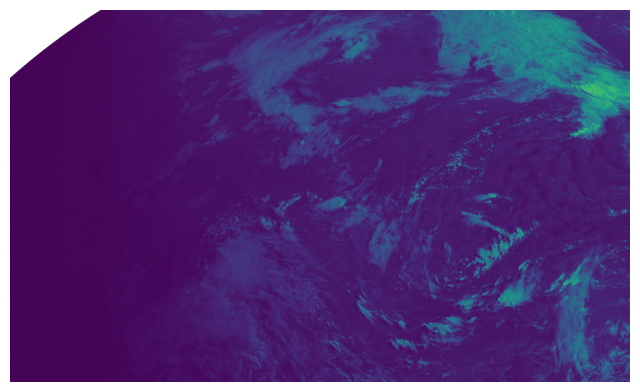

In [60]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("output/img8.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

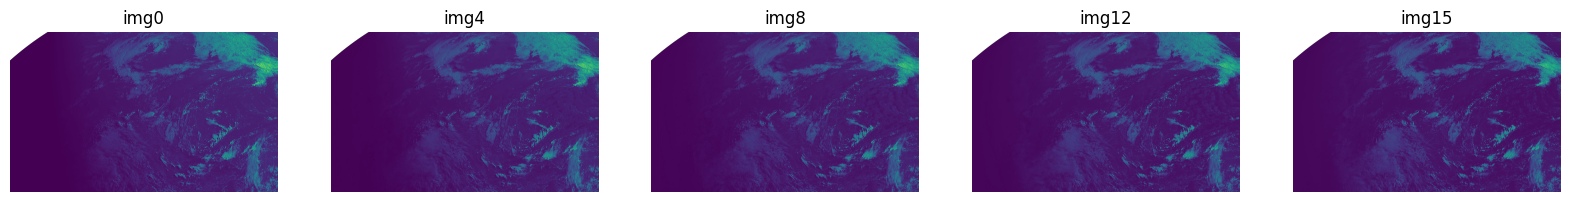

In [61]:
from PIL import Image
import matplotlib.pyplot as plt

frames = [0,4,8,12,15]

fig, ax = plt.subplots(1,5, figsize=(20,5))

for i, idx in enumerate(frames):
    img = Image.open(f"output/img{idx}.png")
    ax[i].imshow(img)
    ax[i].set_title(f"img{idx}")
    ax[i].axis("off")

plt.show()

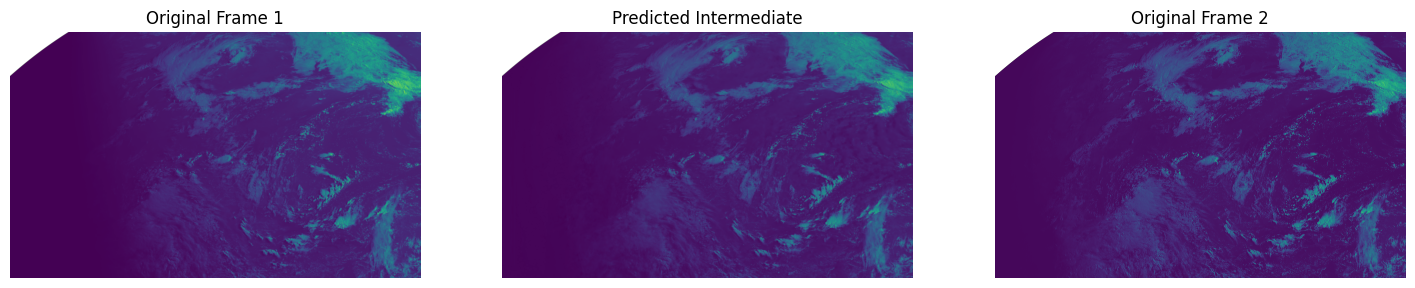

In [62]:
from PIL import Image
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow(Image.open("frame1.png"))
ax[0].set_title("Original Frame 1")

ax[1].imshow(Image.open("output/img8.png"))
ax[1].set_title("Predicted Intermediate")

ax[2].imshow(Image.open("frame2.png"))
ax[2].set_title("Original Frame 2")

for a in ax:
    a.axis("off")

plt.show()

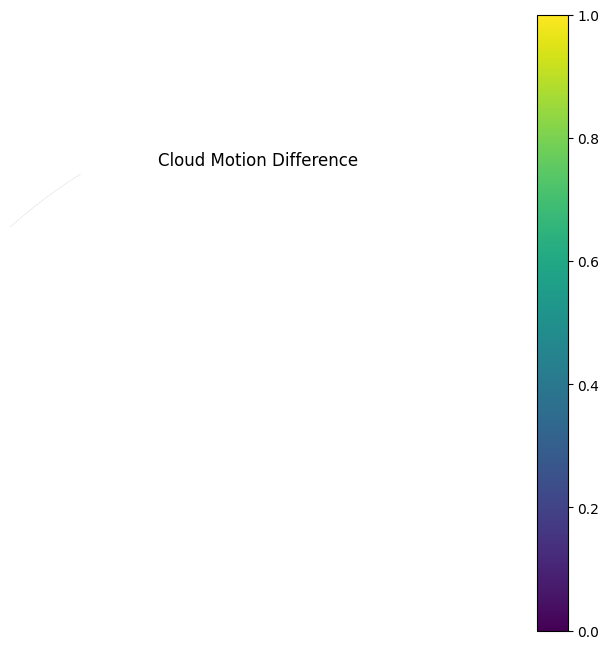

In [63]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img1 = np.array(Image.open("frame1.png")).astype(float)
img2 = np.array(Image.open("frame2_fixed.png")).astype(float)

diff = np.abs(img2 - img1)

plt.figure(figsize=(8,8))
plt.imshow(diff)
plt.title("Cloud Motion Difference")
plt.axis("off")
plt.colorbar()
plt.show()

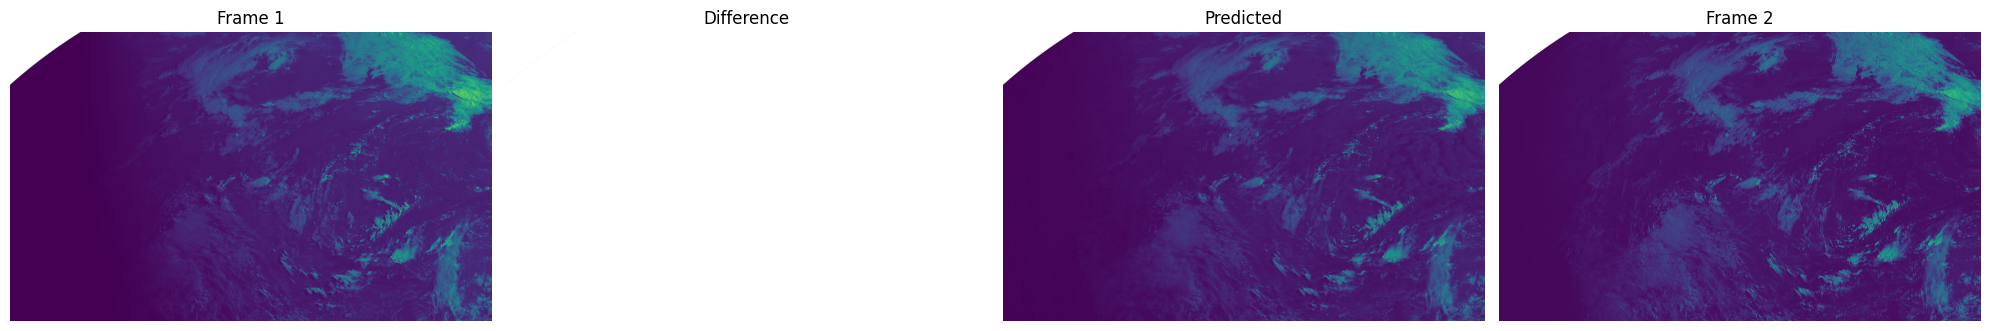

In [64]:
from PIL import Image
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,4, figsize=(20,5))

ax[0].imshow(Image.open("frame1.png"))
ax[0].set_title("Frame 1")

ax[1].imshow(diff.astype("uint8"))
ax[1].set_title("Difference")

ax[2].imshow(Image.open("output/img8.png"))
ax[2].set_title("Predicted")

ax[3].imshow(Image.open("frame2.png"))
ax[3].set_title("Frame 2")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.savefig("final_result.png")
plt.show()

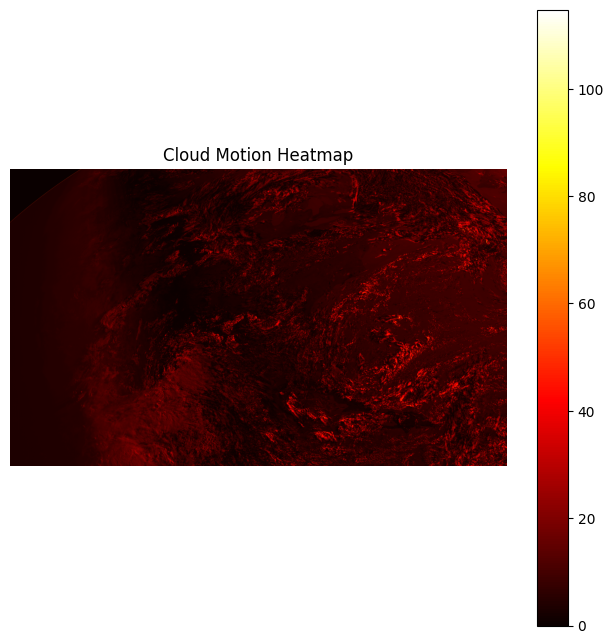

In [65]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img1 = np.array(Image.open("frame1.png")).astype(float)
img2 = np.array(Image.open("frame2_fixed.png")).astype(float)

diff = np.abs(img2 - img1)

plt.figure(figsize=(8,8))
plt.imshow(diff.mean(axis=2), cmap="hot")
plt.colorbar()
plt.title("Cloud Motion Heatmap")
plt.axis("off")
plt.show()

In [68]:
!pip install scikit-image

In [69]:
from PIL import Image
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio

img1 = np.array(Image.open("frame1.png").convert("L"))
img2 = np.array(Image.open("frame2_fixed.png").convert("L"))

ssim_score = ssim(img1, img2)
mse_score = mean_squared_error(img1, img2)
psnr_score = peak_signal_noise_ratio(img1, img2)

print("SSIM :", ssim_score)
print("MSE  :", mse_score)
print("PSNR :", psnr_score)

SSIM : 0.8009117659008792
MSE  : 146.78212593333333
PSNR : 26.464071873119764


In [70]:
from PIL import Image
import numpy as np
from skimage.metrics import structural_similarity as ssim

f1 = np.array(Image.open("frame1.png").convert("L"))
pred = np.array(Image.open("output/img8.png").convert("L"))
f2 = np.array(Image.open("frame2_fixed.png").convert("L"))

print("Frame1 vs Predicted :", ssim(f1, pred))
print("Predicted vs Frame2 :", ssim(pred, f2))

Frame1 vs Predicted : 0.8658187328631473
Predicted vs Frame2 : 0.8415461325875849


In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [72]:
img1 = cv2.imread("frame1.png", 0)
img2 = cv2.imread("frame2_fixed.png", 0)

flow = cv2.calcOpticalFlowFarneback(
    img1,
    img2,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)

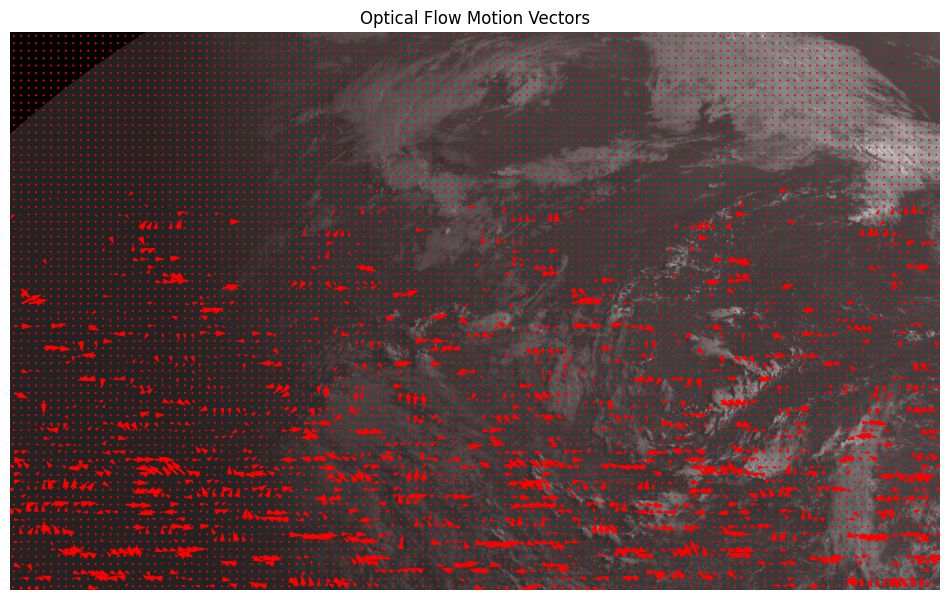

In [84]:
step = 40


y, x = np.mgrid[
    step//2:img1.shape[0]:step,
    step//2:img1.shape[1]:step
]

fx, fy = flow[y, x].T

plt.figure(figsize=(12,8))
plt.imshow(img1, cmap='gray')

plt.quiver(
    x,
    y,
    fx,
    fy,
    color='red',
    angles='xy',
    scale_units='xy',
    scale=0.3
)

plt.title("Optical Flow Motion Vectors")
plt.axis("off")
plt.show()